# Gemma 4 26B distractor-scaling sanity check (Biowulf OnDemand)

Cross-family replication of the CTD distractor-scaling experiment.

**Model:** `google/gemma-4-26B-A4B-it`

This notebook keeps the same underlying CTD examples across distractor counts and uses **nested distractors**:

`D1 ⊂ D3 ⊂ D5 ⊂ D10 ⊂ D20 ⊂ D50`

Primary outputs:
- accuracy vs. distractor count
- false-abstention rate
- distractor-answer rate
- correct-edge position for later analysis

The model is loaded in **BF16** on an A100 80 GB when possible, matching the Qwen3.8-27B strong-model setup more closely than the quantized Llama 4 Scout run.


In [1]:
# Environment and paths
import os
from pathlib import Path
from dotenv import load_dotenv

ROOT = Path("/data/LunaLab/yoshi/llm-tuning-playground")
assert ROOT.exists(), f"Repository root not found: {ROOT}"

load_dotenv(ROOT / ".env")

HF_HOME = Path(os.environ.get("HF_HOME", str(ROOT / "hf_cache")))
os.environ["HF_HOME"] = str(HF_HOME)
os.environ["HUGGINGFACE_HUB_CACHE"] = str(HF_HOME / "hub")
os.environ["TRANSFORMERS_CACHE"] = str(HF_HOME / "hub")

HF_HOME.mkdir(parents=True, exist_ok=True)

DATA_DIR = ROOT / "ctd_data"
OUT_DIR = ROOT / "results" / "21_gemma4_26b"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("HF_HOME:", HF_HOME)
print("OUT_DIR:", OUT_DIR)
print("HF_TOKEN loaded:", bool(os.environ.get("HF_TOKEN")))


ROOT: /data/LunaLab/yoshi/llm-tuning-playground
HF_HOME: /data/LunaLab/yoshi/llm-tuning-playground/hf_cache
OUT_DIR: /data/LunaLab/yoshi/llm-tuning-playground/results/21_gemma4_26b
HF_TOKEN loaded: True


In [2]:
import re
import gzip
import random
import requests
import numpy as np
import pandas as pd
import torch

from transformers import AutoProcessor, AutoModelForMultimodalLM

MODEL_NAME = "google/gemma-4-26B-A4B-it"

SEED = 1
N_SCALING = 50
K_VALUES = [0, 1, 3, 5, 10, 20, 50]
SPLITS = ["ChemicalID", "GeneID", "DiseaseID"]
MAX_NEW_TOKENS = 128

assert torch.cuda.is_available(), (
    "No CUDA GPU is visible. Launch the OnDemand Jupyter session with an A100 GPU."
)

props = torch.cuda.get_device_properties(0)

print("GPU:", torch.cuda.get_device_name(0))
print("GPU memory (GiB):", round(props.total_memory / 1024**3, 1))
print("BF16 supported:", torch.cuda.is_bf16_supported())
print("Model:", MODEL_NAME)


GPU: NVIDIA A100-SXM4-80GB
GPU memory (GiB): 79.2
BF16 supported: True
Model: google/gemma-4-26B-A4B-it


In [3]:
# CTD acquisition / parsing
CHEM_NAME = "CTD_chem_gene_ixns.tsv.gz"
GD_NAMES = ["CTD_curated_genes_diseases.tsv.gz", "CTD_genes_diseases.tsv.gz"]

def valid_gzip(path, min_bytes=10000):
    path = Path(path)
    if not path.exists() or path.stat().st_size < min_bytes:
        return False
    try:
        with open(path, "rb") as f:
            if f.read(2) != b"\x1f\x8b":
                return False
        with gzip.open(path, "rb") as f:
            f.read(128)
        return True
    except Exception:
        return False

def ensure_file(names):
    if isinstance(names, str):
        names = [names]

    for name in names:
        p = DATA_DIR / name
        if valid_gzip(p):
            print("Found:", p)
            return p

    for name in names:
        dest = DATA_DIR / name
        for url in [
            f"https://ctdbase.org/reports/{name}",
            f"https://ctdbase.org/downloads/{name}",
        ]:
            try:
                print("Downloading:", url)
                with requests.get(
                    url,
                    stream=True,
                    timeout=(20, 300),
                    headers={"User-Agent": "Mozilla/5.0"},
                ) as r:
                    r.raise_for_status()
                    with open(dest, "wb") as f:
                        for chunk in r.iter_content(1024 * 1024):
                            if chunk:
                                f.write(chunk)

                if valid_gzip(dest):
                    return dest

            except Exception as e:
                print("failed:", type(e).__name__, str(e)[:120])

            dest.unlink(missing_ok=True)

    raise FileNotFoundError(names)

def read_ctd(path, expected):
    header = None

    with gzip.open(path, "rt", encoding="utf-8", errors="replace") as f:
        for line in f:
            if not line.startswith("#"):
                break

            s = line.lstrip("#").strip()

            if "\t" in s:
                cols = [x.strip() for x in s.split("\t")]
                if any(x in cols for x in expected):
                    header = cols

    if header is None:
        raise ValueError(f"Header not found: {path}")

    return pd.read_csv(
        path,
        sep="\t",
        comment="#",
        compression="gzip",
        dtype=str,
        low_memory=False,
        header=None,
        names=header,
    )

cg = read_ctd(
    ensure_file(CHEM_NAME),
    ["ChemicalName", "ChemicalID", "GeneSymbol", "GeneID"],
)

gd = read_ctd(
    ensure_file(GD_NAMES),
    ["GeneSymbol", "GeneID", "DiseaseName", "DiseaseID"],
)

cg2 = (
    cg[["ChemicalName", "ChemicalID", "GeneSymbol", "GeneID"]]
    .dropna()
    .drop_duplicates()
)

gd2 = (
    gd[["GeneSymbol", "GeneID", "DiseaseName", "DiseaseID"]]
    .dropna()
    .drop_duplicates()
)

paths = (
    cg2.merge(gd2, on=["GeneSymbol", "GeneID"])
    .drop_duplicates()
)

paths = paths[
    (paths.ChemicalName.str.len() < 100)
    & (paths.DiseaseName.str.len() < 120)
].reset_index(drop=True)

edge_pool = (
    gd2[["GeneSymbol", "DiseaseName"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("paths:", len(paths), "edges:", len(edge_pool))


Found: /data/LunaLab/yoshi/llm-tuning-playground/ctd_data/CTD_chem_gene_ixns.tsv.gz
Found: /data/LunaLab/yoshi/llm-tuning-playground/ctd_data/CTD_curated_genes_diseases.tsv.gz
paths: 9707313 edges: 34272


In [4]:
# Prompt and fixed split helpers

def render(row, edges):
    ev = "\n".join(f"- {g} -> {d}" for g, d in edges)

    return (
        "Use only the supplied evidence. Determine the disease supported by the path "
        "from the queried chemical through the queried gene. "
        "If no supplied gene-disease relation supports the queried gene, answer exactly: "
        "No supported path.\n\n"
        f"Chemical: {row.ChemicalName}\n"
        f"Gene: {row.GeneSymbol}\n"
        f"Evidence:\n{ev}"
    )

def get_fixed_test_examples(split, seed=1, n_eval=50):
    rng_np = np.random.default_rng(seed)

    entities = paths[split].dropna().unique().copy()
    rng_np.shuffle(entities)

    cut = max(1, int(0.8 * len(entities)))
    test_entities = set(entities[cut:])

    test_pool = (
        paths[paths[split].isin(test_entities)]
        .drop_duplicates(["ChemicalID", "GeneID", "DiseaseID"])
    )

    assert len(test_pool) >= n_eval, (
        f"Not enough examples for {split}: {len(test_pool)} available"
    )

    return (
        test_pool
        .sample(n_eval, random_state=1000 + seed)
        .reset_index(drop=True)
    )

def build_nested_distractors(row, max_k=50, seed=1, example_idx=0):
    pool = edge_pool[
        (edge_pool.GeneSymbol != row.GeneSymbol)
        & (edge_pool.DiseaseName != row.DiseaseName)
    ].drop_duplicates()

    assert len(pool) >= max_k

    rs = 50000 + seed * 1000 + example_idx

    sub = pool.sample(
        max_k,
        random_state=rs,
        replace=False,
    )

    return [
        (str(g), str(d))
        for g, d in sub.itertuples(index=False, name=None)
    ]

def make_scaling_item(row, distractors, k, seed, example_idx):
    true_edge = (str(row.GeneSymbol), str(row.DiseaseName))
    edges = [true_edge] + distractors[:k]

    rng = random.Random(
        70000
        + seed * 10000
        + example_idx * 100
        + k
    )
    rng.shuffle(edges)

    return {
        "prompt": render(row, edges),
        "target": str(row.DiseaseName),
        "no_path": False,
        "edges": edges,
        "true_edge_position": edges.index(true_edge),
        "n_edges": len(edges),
    }


## Load Gemma 4 in BF16

Gemma 4 26B is loaded in BF16 with `device_map="auto"`. On an A100 80 GB this should normally fit for short text-only generation. If your local Transformers build reports an unsupported architecture, upgrade `transformers` and restart the kernel.


In [5]:
hf_token = os.environ.get("HF_TOKEN")

processor = AutoProcessor.from_pretrained(
    MODEL_NAME,
    token=hf_token,
    trust_remote_code=True,
)

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_NAME,
    token=hf_token,
    dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

model.eval()

print("loaded")
print("device map:", getattr(model, "hf_device_map", None))
print("allocated GiB:", round(torch.cuda.memory_allocated() / 1024**3, 2))
print("reserved GiB:", round(torch.cuda.memory_reserved() / 1024**3, 2))


Loading weights:   0%|          | 0/1013 [00:00<?, ?it/s]

loaded
device map: None
allocated GiB: 48.07
reserved GiB: 48.1


In [6]:
# Generation and scoring

def generate_one(prompt):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt}
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )

    dev = next(model.parameters()).device
    inputs = {
        k: v.to(dev) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
        )

    n = inputs["input_ids"].shape[-1]

    return processor.tokenizer.decode(
        out[0][n:],
        skip_special_tokens=True,
    ).strip()

def norm(s):
    return re.sub(r"\s+", " ", str(s).strip().lower())

def classify_positive_error(item, prediction):
    pred = norm(prediction)
    target = norm(item["target"])

    if target in pred and "no supported path" not in pred:
        return "correct"

    if "no supported path" in pred:
        return "false_abstention"

    distractor_diseases = {
        norm(d)
        for g, d in item["edges"]
        if norm(d) != target
    }

    if any(d and d in pred for d in distractor_diseases):
        return "distractor_answer"

    return "other_wrong_answer"


In [7]:
# One-example preflight before the full run

_pre_test = get_fixed_test_examples(
    split="DiseaseID",
    seed=SEED,
    n_eval=1,
)

_pre_row = _pre_test.iloc[0]

_pre_distractors = build_nested_distractors(
    row=_pre_row,
    max_k=max(K_VALUES),
    seed=SEED,
    example_idx=0,
)

_pre_item = make_scaling_item(
    row=_pre_row,
    distractors=_pre_distractors,
    k=5,
    seed=SEED,
    example_idx=0,
)

_pre_pred = generate_one(_pre_item["prompt"])

print("Target:", _pre_item["target"])
print("Prediction:", _pre_pred)
print("Type:", classify_positive_error(_pre_item, _pre_pred))


Target: Drug Hypersensitivity
Prediction: Drug Hypersensitivity
Type: correct


In [8]:
# Full distractor-scaling run

SCALING_RESULTS_CSV = (
    OUT_DIR / "21_gemma4_26b_distractor_scaling_results.csv"
)

SCALING_SUMMARY_CSV = (
    OUT_DIR / "21_gemma4_26b_distractor_scaling_summary.csv"
)

scaling_rows = []

for split in SPLITS:

    print("\n" + "#" * 80)
    print("SPLIT:", split)
    print("#" * 80)

    test = get_fixed_test_examples(
        split=split,
        seed=SEED,
        n_eval=N_SCALING,
    )

    distractor_bank = {}

    for i, row in test.iterrows():
        distractor_bank[i] = build_nested_distractors(
            row=row,
            max_k=max(K_VALUES),
            seed=SEED,
            example_idx=i,
        )

    for k in K_VALUES:

        print("\n" + "=" * 70)
        print(f"{split} | distractor_{k}")
        print("=" * 70)

        k_rows = []

        for i, row in test.iterrows():

            item = make_scaling_item(
                row=row,
                distractors=distractor_bank[i],
                k=k,
                seed=SEED,
                example_idx=i,
            )

            pred = generate_one(item["prompt"])

            error_type = classify_positive_error(
                item,
                pred,
            )

            correct = int(error_type == "correct")

            result = {
                "model": MODEL_NAME,
                "split": split,
                "seed": SEED,
                "k": k,
                "example_idx": i,

                "ChemicalID": row.ChemicalID,
                "GeneID": row.GeneID,
                "DiseaseID": row.DiseaseID,

                "ChemicalName": row.ChemicalName,
                "GeneSymbol": row.GeneSymbol,
                "target": row.DiseaseName,

                "prediction": pred,
                "correct": correct,
                "error_type": error_type,

                "true_edge_position": item["true_edge_position"],
                "n_edges": item["n_edges"],
            }

            scaling_rows.append(result)
            k_rows.append(result)

            if i < 3:
                print(
                    i,
                    correct,
                    error_type,
                    "| pos:",
                    item["true_edge_position"],
                    "|",
                    pred[:120],
                )

            if (i + 1) % 10 == 0:
                pd.DataFrame(scaling_rows).to_csv(
                    SCALING_RESULTS_CSV,
                    index=False,
                )
                print(f"checkpoint {i + 1}/{len(test)}")

        acc = np.mean([r["correct"] for r in k_rows])

        false_abstain_rate = np.mean([
            r["error_type"] == "false_abstention"
            for r in k_rows
        ])

        print(
            f"k={k} | "
            f"accuracy={acc:.3f} | "
            f"false_abstention={false_abstain_rate:.3f}"
        )

scaling_df = pd.DataFrame(scaling_rows)

scaling_df.to_csv(
    SCALING_RESULTS_CSV,
    index=False,
)

print("Saved:", SCALING_RESULTS_CSV)



################################################################################
SPLIT: ChemicalID
################################################################################

ChemicalID | distractor_0
0 0 false_abstention | pos: 0 | No supported path.
1 1 correct | pos: 0 | Prostatic Neoplasms
2 1 correct | pos: 0 | Heart Failure
checkpoint 10/50
checkpoint 20/50
checkpoint 30/50
checkpoint 40/50
checkpoint 50/50
k=0 | accuracy=0.820 | false_abstention=0.140

ChemicalID | distractor_1
0 1 correct | pos: 1 | Macrocephaly, Alopecia, Cutis Laxa, and Scoliosis
1 1 correct | pos: 1 | Prostatic Neoplasms
2 1 correct | pos: 0 | Heart Failure
checkpoint 10/50
checkpoint 20/50
checkpoint 30/50
checkpoint 40/50
checkpoint 50/50
k=1 | accuracy=0.860 | false_abstention=0.120

ChemicalID | distractor_3
0 1 correct | pos: 3 | Macrocephaly, Alopecia, Cutis Laxa, and Scoliosis
1 1 correct | pos: 0 | Prostatic Neoplasms
2 1 correct | pos: 2 | Heart Failure
checkpoint 10/50
checkpoint 20/50
check

In [9]:
# Summary

scaling_summary = (
    scaling_df
    .groupby(["split", "k"], as_index=False)
    .agg(
        accuracy=("correct", "mean"),
        n=("correct", "size"),
        false_abstention_rate=(
            "error_type",
            lambda x: np.mean(x == "false_abstention"),
        ),
        distractor_answer_rate=(
            "error_type",
            lambda x: np.mean(x == "distractor_answer"),
        ),
        other_wrong_rate=(
            "error_type",
            lambda x: np.mean(x == "other_wrong_answer"),
        ),
    )
)

scaling_summary.to_csv(
    SCALING_SUMMARY_CSV,
    index=False,
)

display(scaling_summary.round(3))

print("Saved:", SCALING_SUMMARY_CSV)


,split,k,accuracy,n,false_abstention_rate,distractor_answer_rate,other_wrong_rate
0,ChemicalID,0,0.82,50,0.14,0.0,0.04
1,ChemicalID,1,0.86,50,0.12,0.0,0.02
2,ChemicalID,3,0.88,50,0.08,0.0,0.04
3,ChemicalID,5,0.90,50,0.08,0.0,0.02
4,ChemicalID,10,0.90,50,0.10,0.0,0.00
5,ChemicalID,20,0.92,50,0.08,0.0,0.00
6,ChemicalID,50,0.94,50,0.06,0.0,0.00
7,DiseaseID,0,0.80,50,0.10,0.0,0.10
8,DiseaseID,1,0.70,50,0.22,0.0,0.08
9,DiseaseID,3,0.80,50,0.12,0.0,0.08


Saved: /data/LunaLab/yoshi/llm-tuning-playground/results/21_gemma4_26b/21_gemma4_26b_distractor_scaling_summary.csv


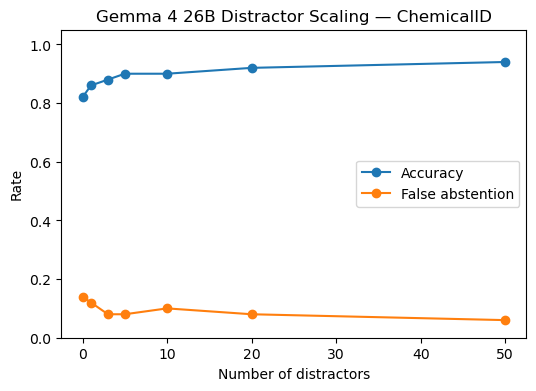

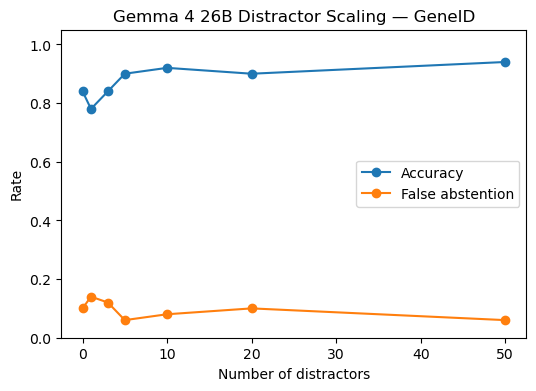

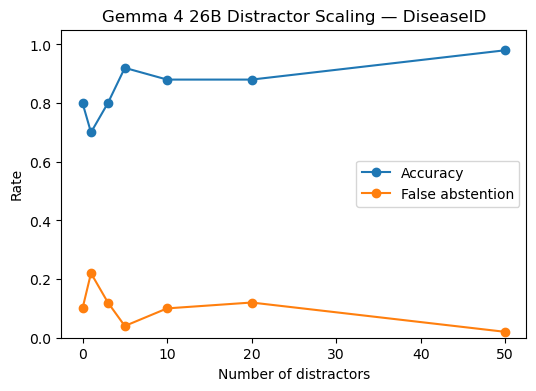

In [10]:
# Per-split scaling curves

import matplotlib.pyplot as plt

for split in SPLITS:
    sub = (
        scaling_summary[
            scaling_summary["split"] == split
        ]
        .sort_values("k")
    )

    plt.figure(figsize=(6, 4))

    plt.plot(
        sub["k"],
        sub["accuracy"],
        marker="o",
        label="Accuracy",
    )

    plt.plot(
        sub["k"],
        sub["false_abstention_rate"],
        marker="o",
        label="False abstention",
    )

    plt.xlabel("Number of distractors")
    plt.ylabel("Rate")
    plt.ylim(0, 1.05)
    plt.title(
        f"Gemma 4 26B Distractor Scaling — {split}"
    )
    plt.legend()
    plt.show()
